In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map

In [2]:
path_to_data = "/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/nuGun_pT_0_50_reco_0.h5"

df = pd.read_hdf(path_to_data, key="df") 
print(df)



          event                    collection  \
0             0  InnerTrackerBarrelCollection   
1             0  InnerTrackerBarrelCollection   
2             0  InnerTrackerBarrelCollection   
3             0  InnerTrackerBarrelCollection   
4             0  InnerTrackerBarrelCollection   
...         ...                           ...   
26580638      0        VertexEndcapCollection   
26580639      0        VertexEndcapCollection   
26580640      0        VertexEndcapCollection   
26580641      0        VertexEndcapCollection   
26580642      0        VertexEndcapCollection   

                                                     object  \
0         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
1         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
2         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
3         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
4         <class cppyy.gbl.IOIMPL.SimTrackerHitIOImpl at...   
...                              

In [4]:
NUM_R0WS = 26_580_643

{0, 1, 2, 3, 4, 5, 6}


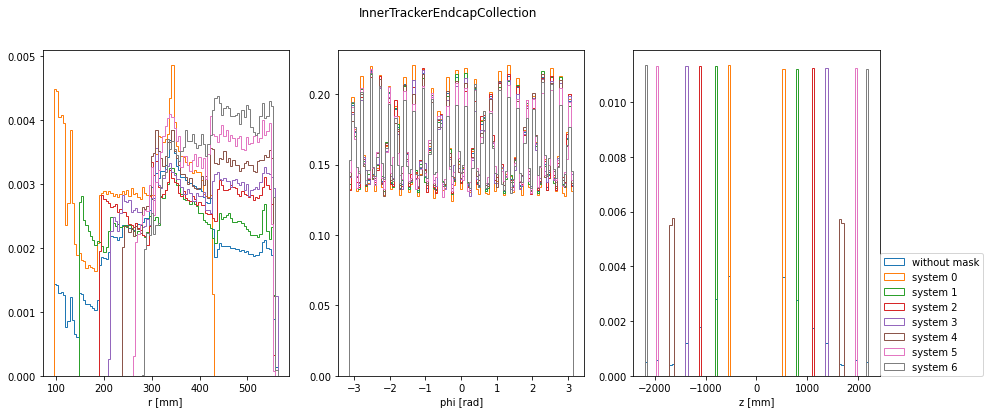

In [29]:
df_col =  df[df["collection"] == "InnerTrackerEndcapCollection"]


system =  df_col[["system"]].to_numpy()
side =  df_col[["side"]].to_numpy()
layer =  df_col[["layer"]].to_numpy()
module =  df_col[["module"]].to_numpy()

r = np.sqrt(df_col[["x"]].to_numpy()**2 + df_col[["y"]].to_numpy()**2)
phi = np.arctan2(df_col[["y"]].to_numpy(), df_col[["x"]].to_numpy())
z = df_col[["z"]].to_numpy()

print(set(list(layer.flatten())))

fig, ax = plt.subplots(1, 3, figsize = (15, 6))

ax[0].hist(r, bins = np.linspace(np.min(r), np.max(r), 100), histtype = "step", label = "without mask", density = True  )
ax[0].set_xlabel("r [mm]")
ax[1].hist(phi, bins = np.linspace(np.min(phi), np.max(phi), 100), range = (-np.pi, np.pi), histtype = "step", label = "without mask", density = True  )
ax[1].set_xlabel("phi [rad]")
ax[2].hist(z, bins = np.linspace(np.min(z), np.max(z), 100), range = (-4000, 4000), histtype = "step", label = "without mask", density = True  )
ax[2].set_xlabel("z [mm]")

for i in range(7):

    mask = (layer == i) 
    ax[0].hist(r[mask], bins = np.linspace(np.min(r), np.max(r), 100), range = (0, 2000), histtype = "step", label = f"system {i}", density = True  )
    ax[1].hist(phi[mask], bins = np.linspace(np.min(phi), np.max(phi), 100), range = (-np.pi, np.pi), histtype = "step", label = f"system {i}", density = True  )
    ax[2].hist(z[mask], bins = np.linspace(np.min(z), np.max(z), 100), range = (-4000, 4000), histtype = "step", label = f"system {i}", density = True  )
ax[2].legend(loc = (1, 0))

plt.suptitle("InnerTrackerEndcapCollection")

plt.show()


In [23]:
collections = [
    "InnerTrackerBarrelCollection",
    "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]

for col in collections:
    df_col = df[df["collection"] == col]
    print(col, len(df_col))



    df_col_selected = df_col[["Edep", "x", "y", "z", "t", "side", "layer"]].to_numpy()

    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/{col}_SimTrackerHit_conditional.npy", df_col_selected)

InnerTrackerBarrelCollection 6639439
InnerTrackerEndcapCollection 2360215
OuterTrackerBarrelCollection 6787500
OuterTrackerEndcapCollection 2825825
VertexBarrelCollection 2641857
VertexEndcapCollection 5325807


# Make geometry map

In [ ]:
geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"

# make_geometry_map(
#     df,
#     collections,
#     geo_map_path,
#     num_events_per_col=1_000_000,
    
# )

In [ ]:
tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

In [ ]:
from tqdm import tqdm

In [ ]:
col_hits_per_layer = {col:{} for col in collections}


dists = []
for i in tqdm(range(0, 26580643, 100)):

    
    event = df.iloc[i]
    col_name = event["collection"]
    layer_truth = event["layer"]
    x_truth, y_truth, z_truth = event["x"], event["y"], event["z"]

    dist, idx = tree_map[col_name].query([x_truth, y_truth, z_truth])
 
    cell_id_returned, layer_returned = cellid_layer_map[col_name][idx]

    if layer_returned != layer_truth:
        print('ERROR', event["collection"], layer_returned, layer_truth, dist)


    try:
        col_hits_per_layer[col_name][layer_returned] += 1
    except KeyError:
        col_hits_per_layer[col_name][layer_returned] = 1
    
        
    dists.append(dist)

    
    

In [ ]:
plt.figure()
plt.hist(dists, bins = 100)
plt.show()

# Flow

In [ ]:
col_hits_per_layer = {col: {} for col in collections}
dists = []

for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    print(small_id)

    flow_samples = np.load(
        f"/pscratch/sd/r/rmastand/muon_collider/zuko_outputs/NCSF/{small_id}_M_4096_rphi/flow_samples.npy"
    )

    # -----------------------------
    # 1. Extract coordinates
    # -----------------------------
    points = flow_samples[:, 1:4]   # shape (N, 3)

    # -----------------------------
    # 2. Mask out NaNs / infs
    # -----------------------------
    valid_mask = np.isfinite(points).all(axis=1)
    points_valid = points[valid_mask]

    # Skip if nothing valid
    if len(points_valid) == 0:
        continue

    # -----------------------------
    # 3. Batch KDTree query
    # -----------------------------
    dists_batch, idx_batch = tree_map[col_name].query(points_valid)

    # -----------------------------
    # 4. Remove invalid KDTree hits
    # -----------------------------
    valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])

    idx_batch = idx_batch[valid_idx_mask]
    dists_batch = dists_batch[valid_idx_mask]

    # -----------------------------
    # 5. Map to (cell_id, layer)
    # -----------------------------
    cell_layer = cellid_layer_map[col_name][idx_batch]
    layers = cell_layer[:, 1]

    # -----------------------------
    # 6. Count hits per layer (vectorized)
    # -----------------------------
    unique_layers, counts = np.unique(layers, return_counts=True)

    for layer, count in zip(unique_layers, counts):
        col_hits_per_layer[col_name][layer] = (
            col_hits_per_layer[col_name].get(layer, 0) + count
        )

    # -----------------------------
    # 7. Collect distances
    # -----------------------------
    dists.append(dists_batch)

In [ ]:
plt.figure()
plt.hist(dists, bins = 100)
plt.yscale("log")
plt.show()

print(col_hits_per_layer)

In [ ]:
print(col_hits_per_layer)

In [ ]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]

# Prepare x positions
width = 0.1  # width of each bar
x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection

fig, ax = plt.subplots(figsize=(12, 6))

# Keep track of total x positions
x_pos = 0
x_labels = []
x_ticks = []

for coll in collections_order:
    layers = sorted(col_hits_per_layer[coll].keys())  # sort layers numerically
    counts = [col_hits_per_layer[coll][l] for l in layers]

    # compute positions for this collection
    positions = x_pos + np.arange(len(layers))
    ax.bar(positions, counts, width=0.8, label=coll)
    
    # collect labels and ticks
    x_labels.extend([f"{l}" for l in layers])
    x_ticks.extend(positions)
    
    # update x_pos for next collection to avoid overlap
    x_pos = positions[-1] + 1  # add gap between collections

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel("Number of hits")
ax.set_title("Hits per Detector Layer")
ax.legend()
plt.tight_layout()
plt.yscale("log")
plt.savefig("figures/hits_per_detector_layer.png")
plt.show()